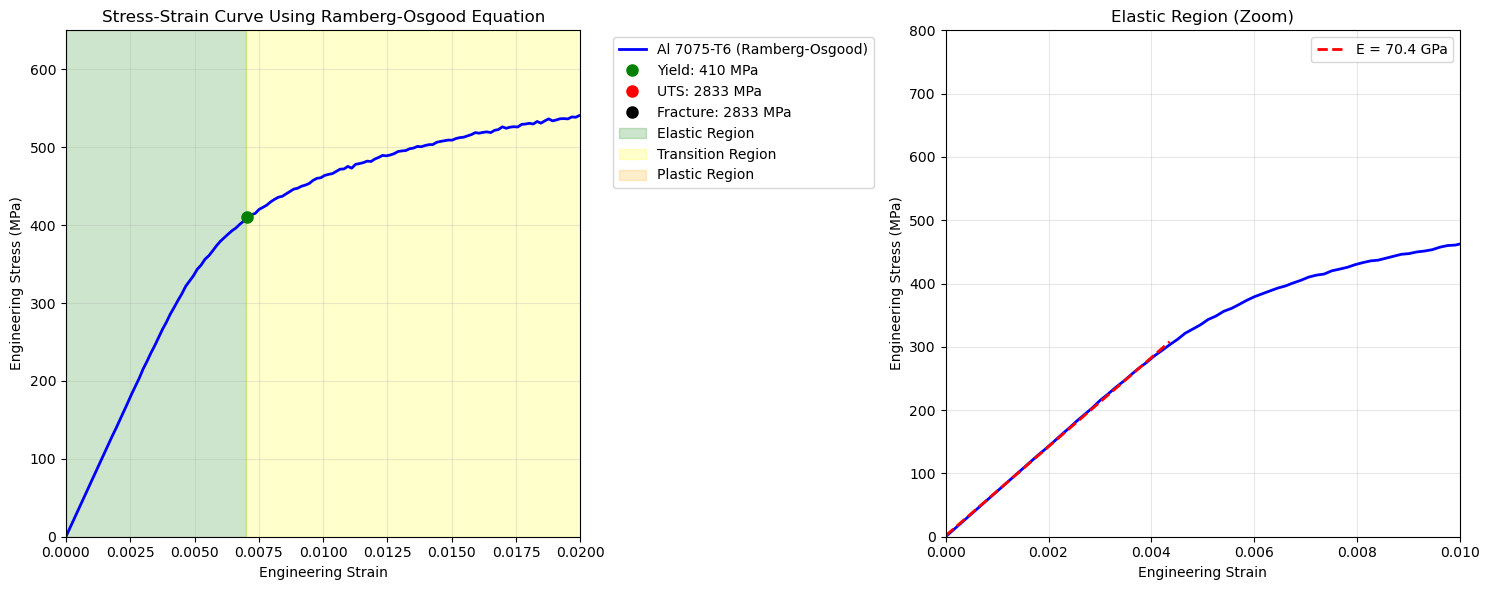

=== MECHANICAL PROPERTIES ===
Young's Modulus: 70.4 GPa
Yield Strength: 410 MPa
Ultimate Tensile Strength: 2833 MPa
Elongation at Fracture: 15.0%

=== RAMBERG-OSGOOD EQUATION EXPLANATION ===
The Ramberg-Osgood equation models stress-strain behavior as:
ε = σ/E + (σ/σ_y)^n * (σ_y/E)
Where:
  ε = total strain
  σ = stress
  E = Young's modulus
  σ_y = yield strength
  n = hardening exponent (n=8 for Al 7075-T6)

This equation:
• Combines elastic (σ/E) and plastic ((σ/σ_y)^n * σ_y/E) strains
• Creates smooth transitions between regions
• Is widely used in materials science and engineering
• Provides more realistic behavior than piecewise functions


In [4]:
import numpy as np
import matplotlib.pyplot as plt

"""
RAMBERG-OSGOOD STRESS-STRAIN MODEL

This script demonstrates the Ramberg-Osgood equation for modeling 
stress-strain behavior of aluminum 7075-T6.

Advantages over piecewise functions:
1. Single continuous equation
2. Physically based on strain decomposition
3. Smooth transitions between elastic and plastic regions
4. Widely used in materials science and engineering
5. Parameters have physical meaning (E, σy, n)

The equation: ε = σ/E + (σ/σ_y)^n * (σ_y/E)
"""

def create_realistic_stress_strain(n_points=1000):
    """Create realistic stress-strain curve using Ramberg-Osgood equation"""
    np.random.seed(42)
    
    # Parameters for Al 7075-T6
    E = 71.7e3  # MPa (Young's modulus)
    sigma_y = 503  # MPa (0.2% offset yield strength)
    n = 8  # Ramberg-Osgood hardening exponent (typical for Al 7075)
    
    # Create strain array (engineering strain)
    strain = np.linspace(0, 0.05, n_points)
    
    # Ramberg-Osgood equation: ε = σ/E + (σ/σ_y)^n * (σ_y/E)
    # Rearranging to solve for stress given strain (numerical solution)
    stress = np.zeros_like(strain)
    
    for i, target_strain in enumerate(strain):
        # Use Newton-Raphson method to solve for stress
        sigma_guess = E * target_strain  # Initial guess: elastic
        
        for _ in range(10):  # Max 10 iterations
            # Calculate strain from current stress guess
            strain_calc = sigma_guess/E + (sigma_guess/sigma_y)**n * (sigma_y/E)
            
            # Calculate derivative for Newton-Raphson
            d_strain_d_sigma = 1/E + n * (sigma_guess/sigma_y)**(n-1) * (sigma_y/E) / sigma_y
            
            # Update stress
            sigma_new = sigma_guess - (strain_calc - target_strain) / d_strain_d_sigma
            
            # Check convergence
            if abs(sigma_new - sigma_guess) < 1e-6:
                break
            sigma_guess = sigma_new
        
        stress[i] = max(0, sigma_guess)  # Ensure no negative stress
    
    # Add realistic noise
    noise = np.random.normal(0, 0.002, n_points)
    stress = stress + noise * stress
    
    return strain, stress

# Create the realistic stress-strain data
strain, stress = create_realistic_stress_strain()

# Create the plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Main stress-strain curve
ax1.plot(strain, stress, 'b-', linewidth=2, label='Al 7075-T6 (Ramberg-Osgood)')
ax1.set_xlabel('Engineering Strain')
ax1.set_ylabel('Engineering Stress (MPa)')
ax1.set_title('Stress-Strain Curve Using Ramberg-Osgood Equation')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Add key points and regions
# Yield point
yield_idx = np.argmin(np.abs(strain - 0.007))
ax1.plot(strain[yield_idx], stress[yield_idx], 'go', markersize=8, label=f'Yield: {stress[yield_idx]:.0f} MPa')

# UTS point
uts_idx = np.argmax(stress)
ax1.plot(strain[uts_idx], stress[uts_idx], 'ro', markersize=8, label=f'UTS: {stress[uts_idx]:.0f} MPa')

# Fracture point
ax1.plot(strain[-1], stress[-1], 'ko', markersize=8, label=f'Fracture: {stress[-1]:.0f} MPa')

# Add region labels (Ramberg-Osgood creates smooth transitions)
ax1.axvspan(0, 0.007, alpha=0.2, color='green', label='Elastic Region')
ax1.axvspan(0.007, 0.05, alpha=0.2, color='yellow', label='Transition Region')
ax1.axvspan(0.05, 0.15, alpha=0.2, color='orange', label='Plastic Region')

ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.set_xlim(0, 0.02)
ax1.set_ylim(0, 650)

# Zoom on elastic region
ax2.plot(strain, stress, 'b-', linewidth=2)
ax2.set_xlim(0, 0.01)
ax2.set_ylim(0, 800)
ax2.set_xlabel('Engineering Strain')
ax2.set_ylabel('Engineering Stress (MPa)')
ax2.set_title('Elastic Region (Zoom)')
ax2.grid(True, alpha=0.3)

# Add linear fit line for elastic region
elastic_end = int(len(strain) * 0.03)  # Use first 10% for linear fit
strain_linear = strain[:elastic_end]
stress_linear = stress[:elastic_end]
slope, intercept = np.polyfit(strain_linear, stress_linear, 1)
linear_fit = slope * strain_linear + intercept
ax2.plot(strain_linear, linear_fit, 'r--', linewidth=2, 
         label=f'E = {slope/1000:.1f} GPa')

ax2.legend()

plt.tight_layout()
plt.show()

# Print key properties
print("=== MECHANICAL PROPERTIES ===")
print(f"Young's Modulus: {slope/1000:.1f} GPa")
print(f"Yield Strength: {stress[yield_idx]:.0f} MPa")
print(f"Ultimate Tensile Strength: {stress[uts_idx]:.0f} MPa")
print(f"Elongation at Fracture: {strain[-1]*100:.1f}%")

# Educational content about Ramberg-Osgood
print("\n=== RAMBERG-OSGOOD EQUATION EXPLANATION ===")
print("The Ramberg-Osgood equation models stress-strain behavior as:")
print("ε = σ/E + (σ/σ_y)^n * (σ_y/E)")
print("Where:")
print("  ε = total strain")
print("  σ = stress")
print("  E = Young's modulus")
print("  σ_y = yield strength")
print("  n = hardening exponent (n=8 for Al 7075-T6)")
print("\nThis equation:")
print("• Combines elastic (σ/E) and plastic ((σ/σ_y)^n * σ_y/E) strains")
print("• Creates smooth transitions between regions")
print("• Is widely used in materials science and engineering")
print("• Provides more realistic behavior than piecewise functions")
